# NAVYA Machine-Learning Pipeline — Team Guide

This notebook is the single revision guide for the complete NAVYA next-cycle-length pipeline. Read it in order to understand what every notebook does, why it exists, which file it reads or writes, and how the final model behaves in deployment.

**Target:** `next_cycle_length_days` only. This project is proof-of-concept work on simulated women, not clinical validation.

## Pipeline at a glance

`Raw CSV → exploration → preprocessing → 18 features → woman-wise model comparison → one GroupKFold tuning decision → diagnostics → uncertainty calibration → final test evaluation → export and inference`

The raw CSV is never modified. Multiple supervised windows belong to the same simulated woman, so all model partitions are woman-wise.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT=Path.cwd().resolve(); ROOT=ROOT if (ROOT/'data').exists() else ROOT.parent
METRICS=ROOT/'results'/'metrics'; PLOTS=ROOT/'results'/'plots'; TUNING=ROOT/'results'/'tuning'
def show_image(path):
    if path.exists(): display(Image(filename=str(path)))
    else: display(Markdown(f'*Run the relevant notebook to generate `{path.name}`.*'))
def show_json(path):
    if path.exists(): display(pd.json_normalize(json.loads(path.read_text())))
    else: display(Markdown(f'*Result artifact not generated yet: `{path.name}`.*'))
print('Project root:',ROOT)

Project root: D:\PROJECT\New_Model_Train


# 01 — Data Exploration

**Purpose:** Understand the untouched dataset before modelling.

**What it does:** Loads the raw CSV; reports schema, missingness, duplicates, categorical distributions, target/history distributions, broad ranges, correlations, and baseline performance. It verifies that there is no explicit woman ID and audits the expected 20 ordered windows per woman using sliding-window continuity.

**Key lesson:** The previous-three-cycle average is a serious baseline. A complex model is useful only if it improves on this simple personal-history estimate.

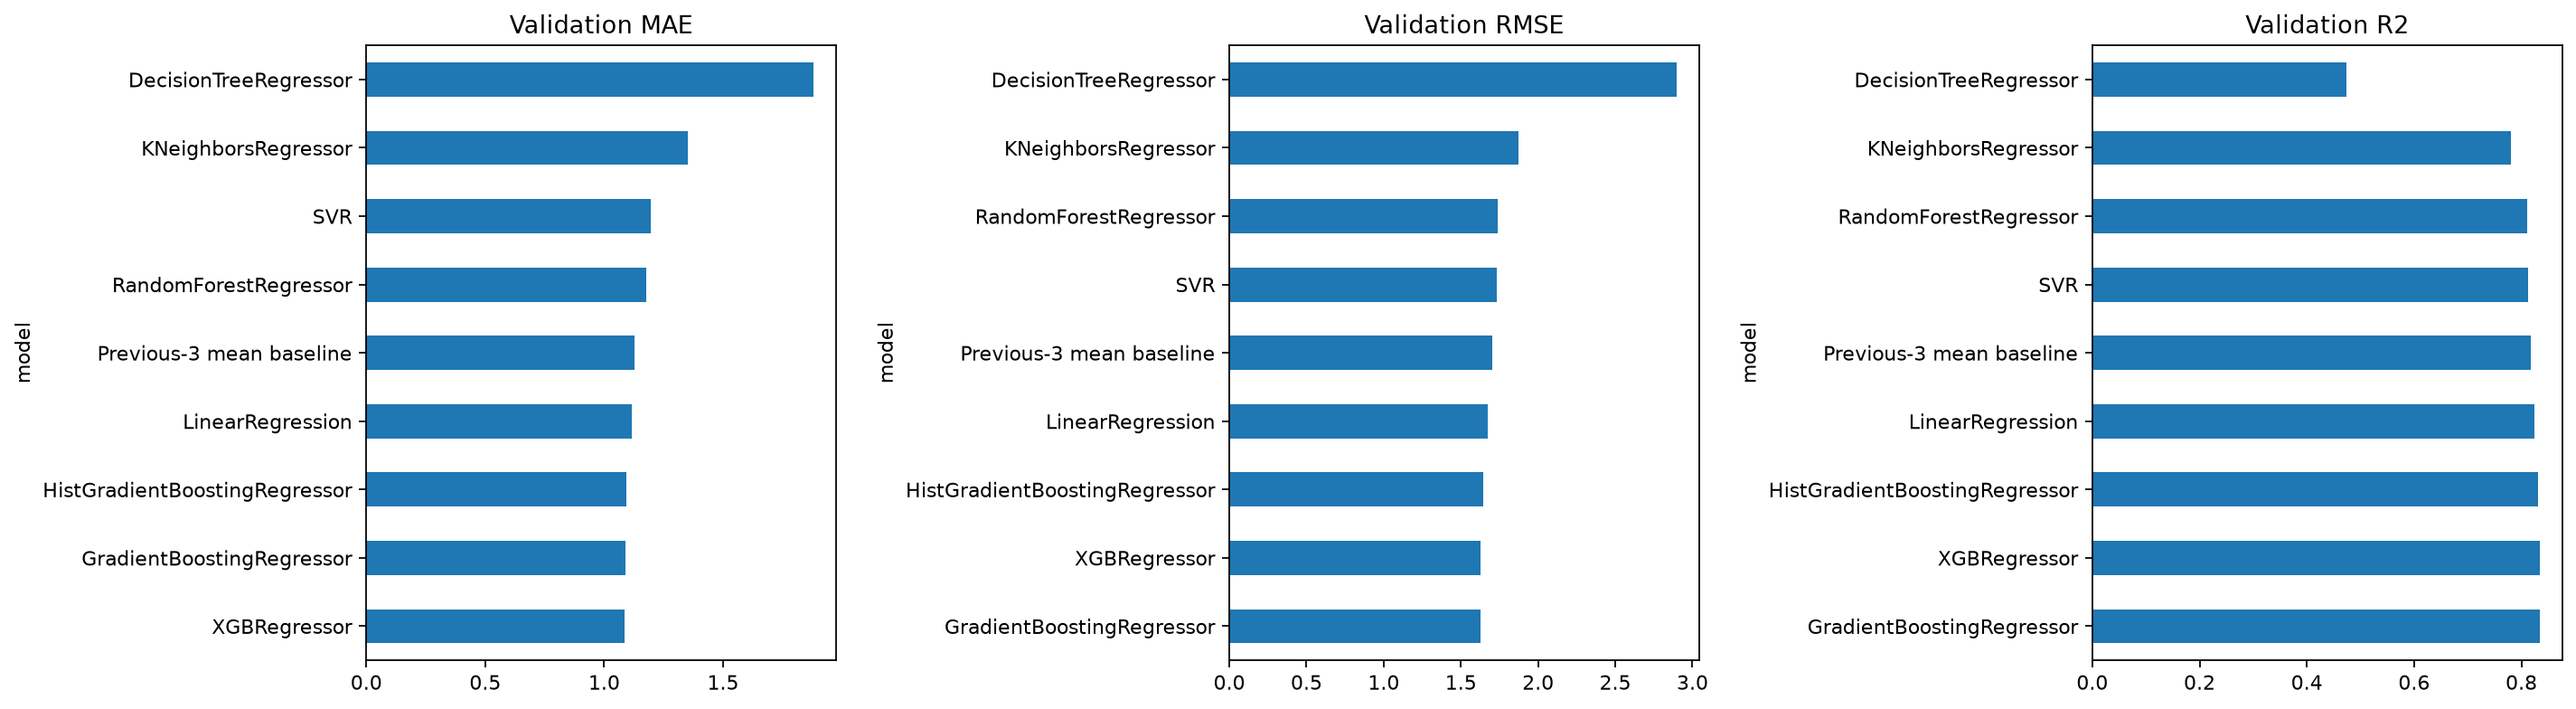

In [2]:
show_image(PLOTS/'initial_model_comparison.png')

# 02 — Data Preprocessing

**Purpose:** Convert raw dataset values into clean app-compatible fields without changing the source CSV.

**What it does:** Reconstructs `woman_id` and `window_index` only after validating the 20-row simulator structure; maps stress/exercise/medication values; converts numeric fields; and writes `processed_data/cleaned_dataset.csv`.

**Important correction:** Heights such as `5.8` are feet-and-inches style (5 ft 8 in), not decimal feet. Height is converted with feet + inches, then BMI is recalculated from converted height and weight.

# 03 — Feature Engineering

**Purpose:** Create exactly the 18 numerical features expected by the NAVYA app model contract.

**What it does:** Renames previous-cycle and period columns; creates previous-three-cycle mean, population standard deviation (`ddof=0`), and previous-three-period mean; checks formulas and target leakage; then writes `processed_data/model_ready_dataset.csv`.

`woman_id` and `window_index` are retained only for splitting—not as model features.

# 04 — Model Training

**Purpose:** Establish an honest baseline comparison across the requested candidate models.

**What it does:** Creates the deterministic woman-wise 800/100/100 split, proves zero woman overlap, fits all candidate pipelines, and compares validation MAE, MSE, RMSE, and R² against the previous-three-cycle baseline.

**Why MAE:** It reports the average error directly in days, making it easy to explain to users and panelists.

,model,MAE,MSE,RMSE,R2
0,XGBRegressor,1.0877,2.6563,1.6298,0.8338
1,GradientBoostingRegressor,1.0889,2.6506,1.6281,0.8342
2,HistGradientBoostingRegressor,1.0940,2.6981,1.6426,0.8312
3,LinearRegression,1.1174,2.8040,1.6745,0.8246
4,Previous-3 mean baseline,1.1260,2.9110,1.7062,0.8179
5,RandomForestRegressor,1.1760,3.0146,1.7363,0.8114
6,SVR,1.1973,3.0011,1.7324,0.8122
7,KNeighborsRegressor,1.3507,3.5103,1.8736,0.7804
8,DecisionTreeRegressor,1.8815,8.3995,2.8982,0.4745


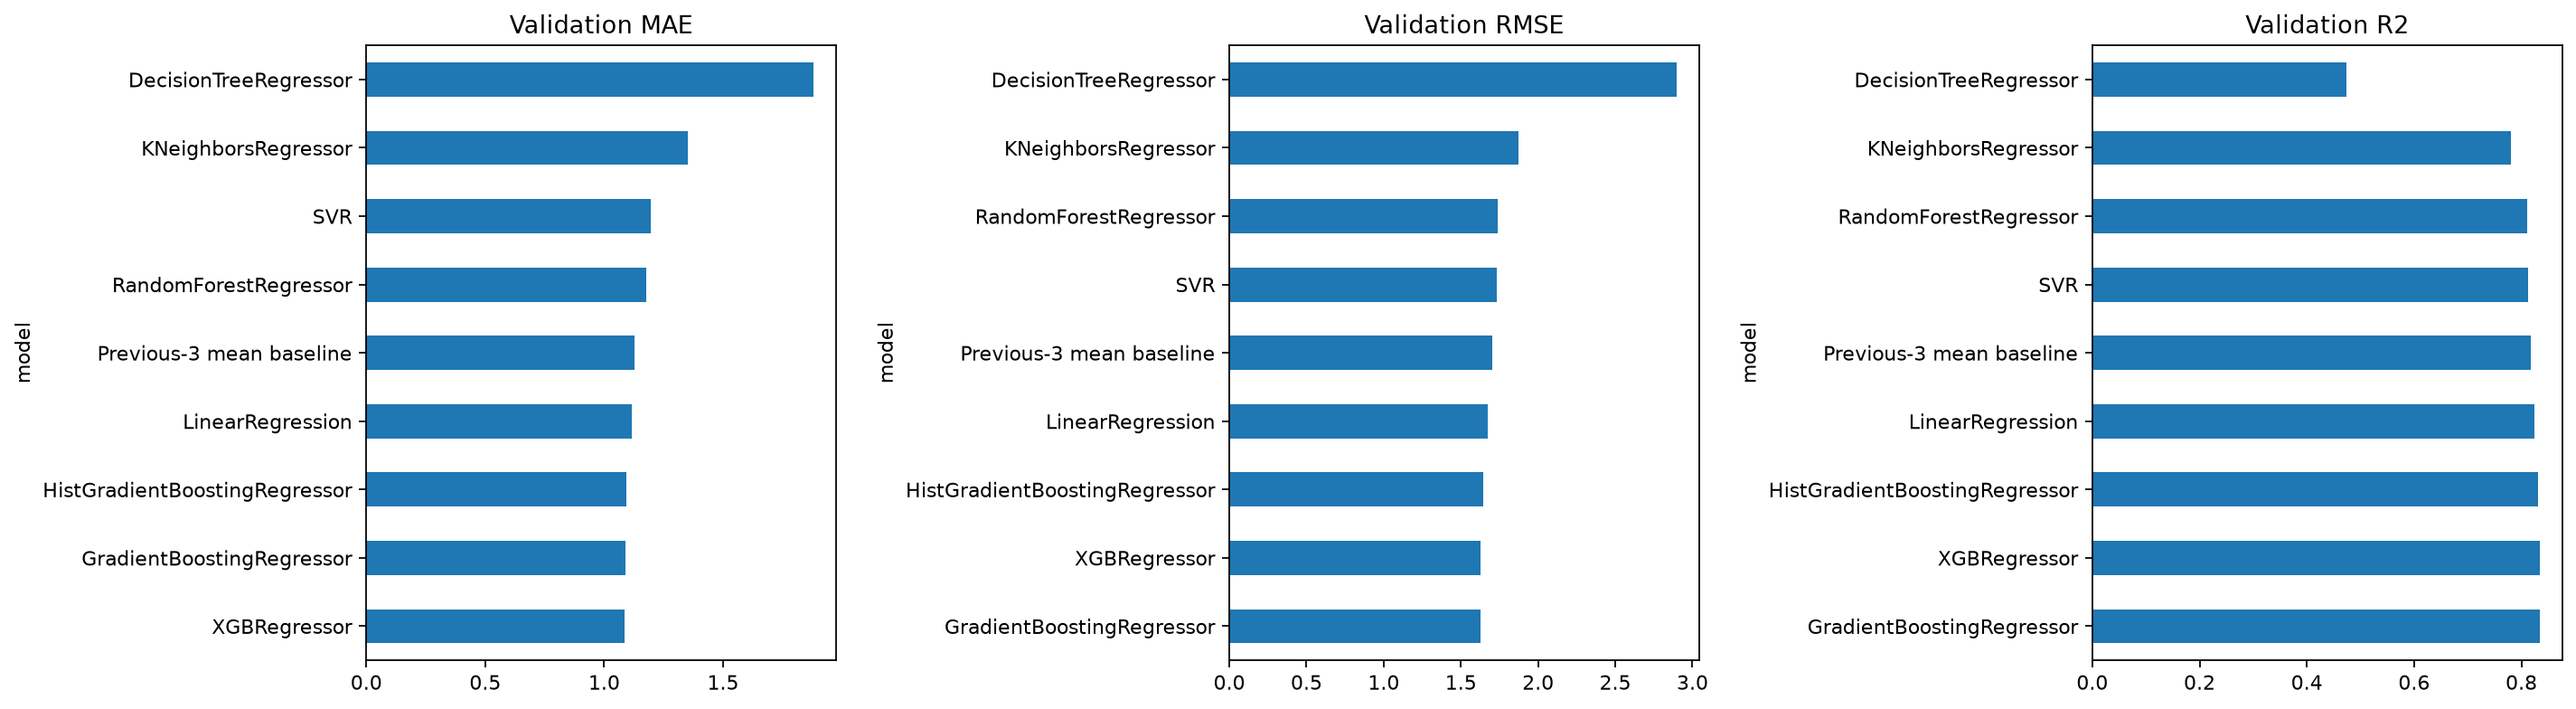

In [3]:
comparison_path=METRICS/'initial_model_comparison.csv'
if comparison_path.exists(): display(pd.read_csv(comparison_path).round(4))
show_image(PLOTS/'initial_model_comparison.png')

# 05 — Hyperparameter Tuning

**Purpose:** Make the one authoritative model-selection decision.

**What it does:** Tunes the promising models using `RandomizedSearchCV`, four-fold `GroupKFold`, and `neg_mean_absolute_error`. Every fold keeps all windows from a woman together. It saves `best_tuned_model.json` and the tuning leaderboard.

**Rule:** All later notebooks read this selected model and its parameters; they do not manually choose a different configuration.

In [4]:
show_json(TUNING/'best_tuned_model.json')
if (TUNING/'tuning_leaderboard.csv').exists(): display(pd.read_csv(TUNING/'tuning_leaderboard.csv').round(4))

,model,best_cv_mae,runtime_seconds,best_params.model__subsample,best_params.model__n_estimators,best_params.model__max_depth,best_params.model__learning_rate,best_params.model__colsample_bytree
0,XGBRegressor,1.23323,2.527505,0.9,250,3,0.03,1.0


,model,best_cv_mae,runtime_seconds,best_params
0,XGBRegressor,1.2332,2.5275,"{'model__subsample': 0.9, 'model__n_estimators..."
1,GradientBoostingRegressor,1.2373,27.5468,"{'model__n_estimators': 100, 'model__min_sampl..."
2,HistGradientBoostingRegressor,1.2376,2.7461,"{'model__max_leaf_nodes': 15, 'model__max_iter..."
3,RandomForestRegressor,1.2404,48.5618,"{'model__n_estimators': 350, 'model__min_sampl..."
4,SVR,1.2683,66.2666,"{'model__gamma': 0.03, 'model__epsilon': 0.25,..."


# 06 — Boosting Learning-Curve Diagnostic

**Purpose:** Visual diagnostic for the selected XGBRegressor configuration.

**What it does:** Uses only training and validation women to plot validation MSE after each XGBoost boosting round. The selected `n_estimators` comes from Notebook 05's grouped cross-validation; this notebook does not select a new value and never touches test women.

**How to explain it:** Each tree is a boosting iteration. The chart shows how the selected model's validation loss behaves, not a separate optimization decision.

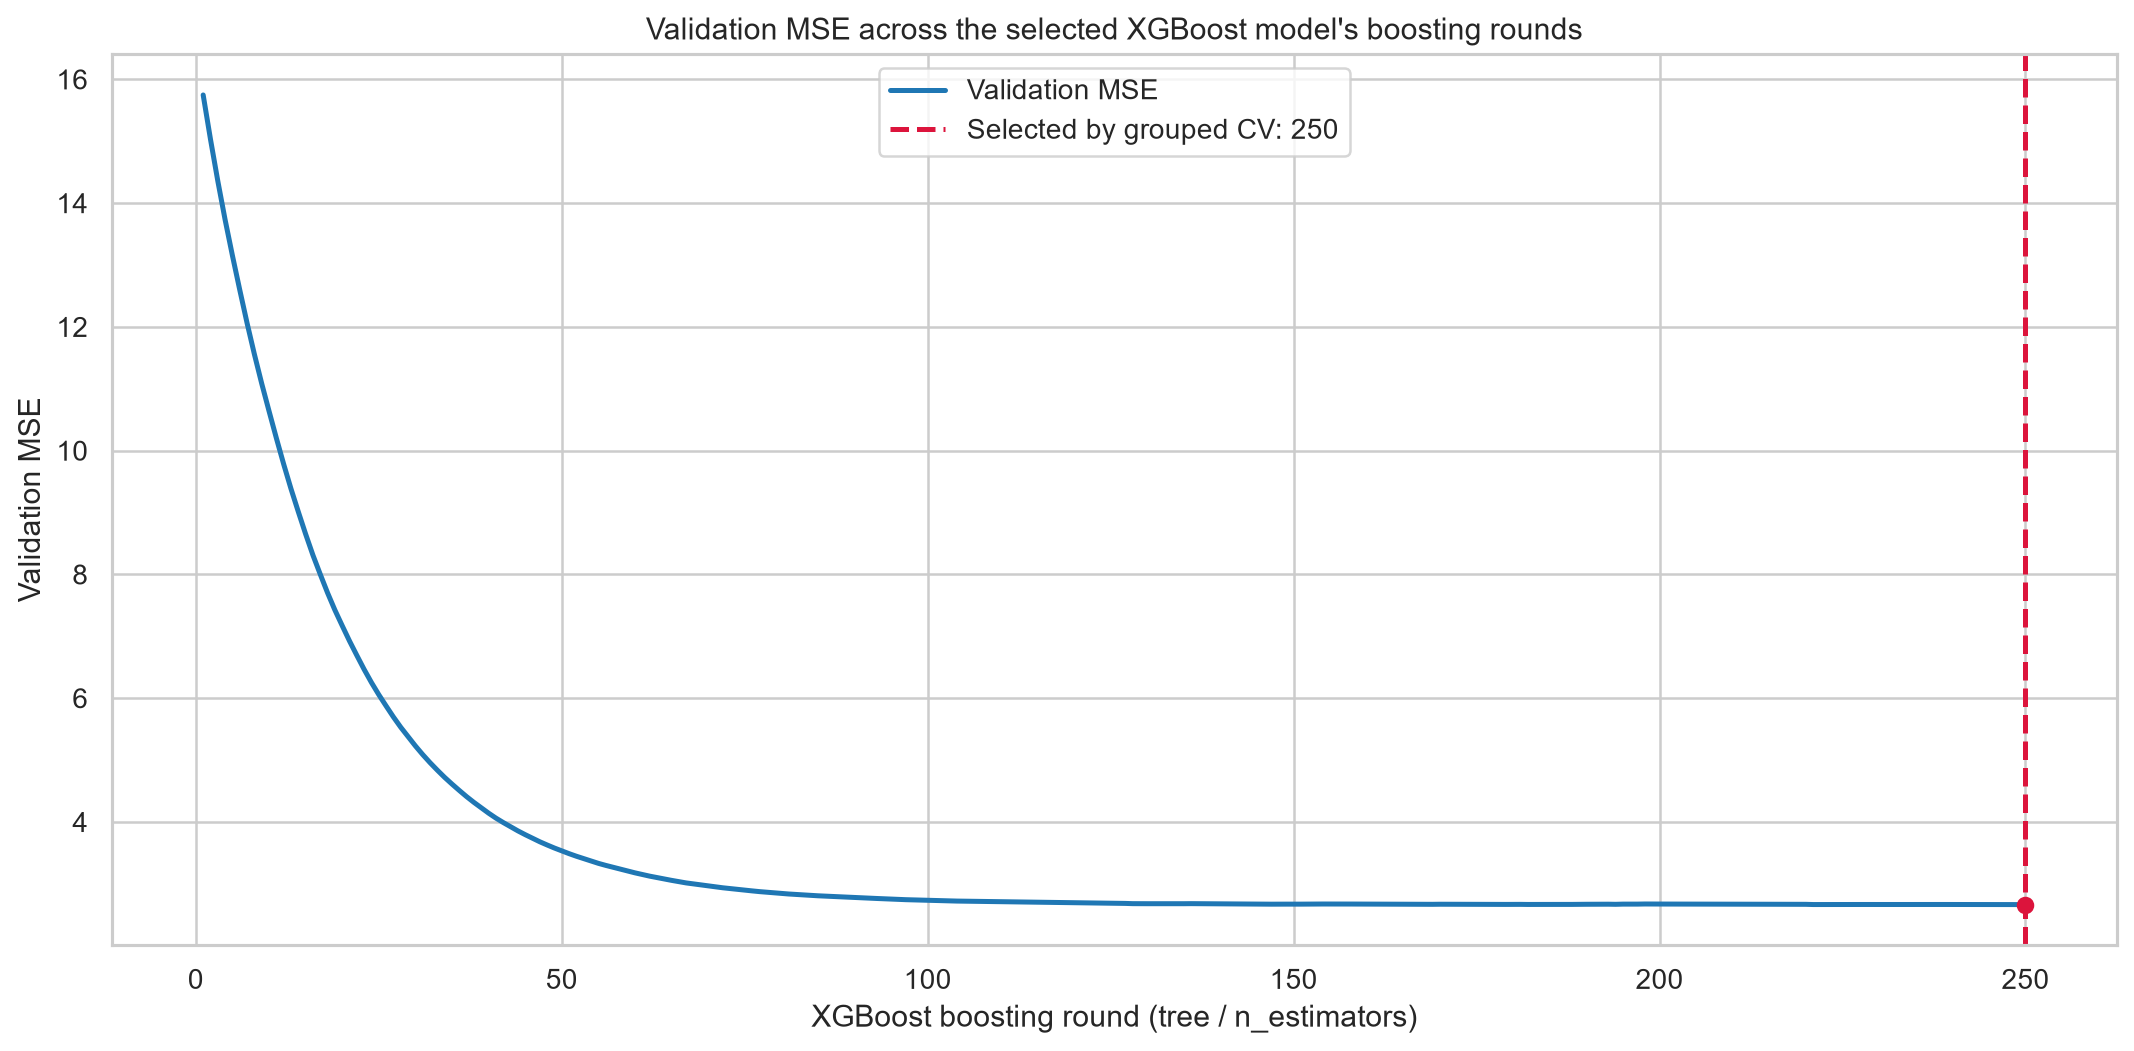

In [5]:
show_image(PLOTS/'xgb_learning_curve.png')

# 07 — Hyperparameter Optimisation Audit

**Purpose:** Presentation-friendly explanation of the tuning decision.

**What it does:** Reads the authoritative Notebook 05 result, displays the grouped-CV ranking and runtime comparison, and explains why the selected configuration won. It intentionally does not run a second tuning process.

**Panel answer:** We used GroupKFold because multiple longitudinal windows belong to one simulated woman; ordinary row splitting would leak person-specific patterns.

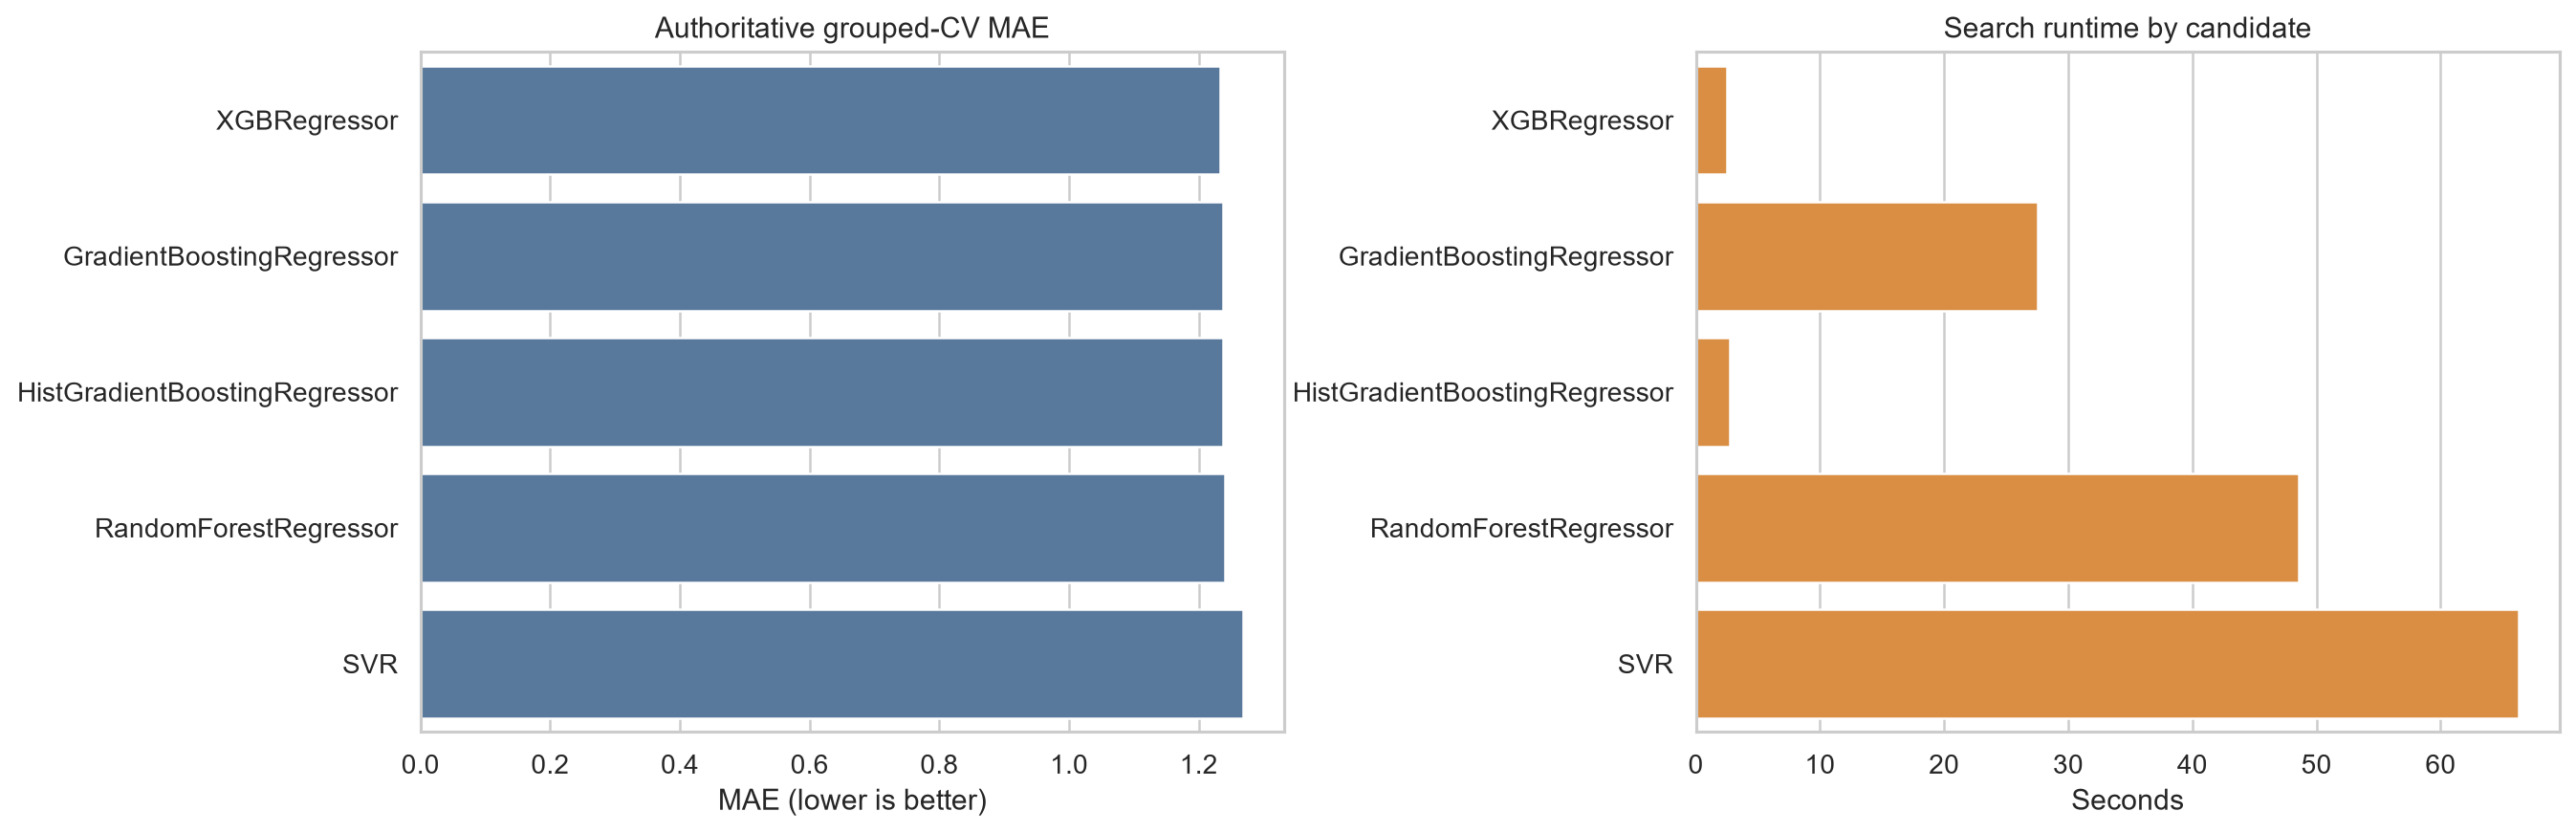

In [6]:
show_image(PLOTS/'hyperparameter_optimisation_audit.png')

# 08 — Uncertainty Calibration

**Purpose:** Add understandable prediction uncertainty without a complicated second model.

**What it does:** Fits the locked pipeline on 800 training women, uses the 100 validation women to calculate 90% split-conformal `q_hat`, and calculates a broad training-support range from the 1st–99th percentiles of prior cycle lengths. It saves the matching fitted pipeline and `uncertainty_calibration.json`.

**Key rule:** The same fitted pipeline is used for calibration, final test predictions, and exported deployment predictions. This is what makes the conformal interval consistent.

In [7]:
show_json(METRICS/'uncertainty_calibration.json')

,uncertainty_method,coverage,q_hat_days,calibration_rows,quantile_level,supported_cycle_lower_bound,supported_cycle_upper_bound,support_rule,selected_model,model_training_women,hyperparameters.model__subsample,hyperparameters.model__n_estimators,hyperparameters.model__max_depth,hyperparameters.model__learning_rate,hyperparameters.model__colsample_bytree
0,split_conformal,0.9,2.172985,2000,0.9005,17.0,39.0,1st to 99th percentile of training previous-cy...,XGBRegressor,800,0.9,250,3,0.03,1.0


# 09 — Model Evaluation

**Purpose:** Perform the first and only final test evaluation.

**What it does:** Loads the locked calibrated pipeline, predicts the untouched 100 test women once, compares it with the previous-three-cycle baseline, reports MAE/RMSE/R² plus within ±1/±2-day rates, and checks observed 90% interval coverage and average interval width.

**Honest interpretation:** Report the measured improvement without exaggeration. Results are proof-of-concept estimates on simulated women.

,selected_model.model,selected_model.best_cv_mae,selected_model.runtime_seconds,selected_model.best_params.model__subsample,selected_model.best_params.model__n_estimators,selected_model.best_params.model__max_depth,selected_model.best_params.model__learning_rate,selected_model.best_params.model__colsample_bytree,final_test_metrics.MAE,final_test_metrics.MSE,...,improvements.mae_improvement_pct,improvements.rmse_improvement,improvements.r2_difference,uncertainty.method,uncertainty.nominal_coverage,uncertainty.q_hat_days,uncertainty.observed_test_coverage,uncertainty.average_interval_width_days,uncertainty.supported_cycle_lower_bound,uncertainty.supported_cycle_upper_bound
0,XGBRegressor,1.23323,2.527505,0.9,250,3,0.03,1.0,1.187209,2.851092,...,2.939755,0.083816,0.021073,split_conformal,0.9,2.172985,0.8685,4.34597,17.0,39.0


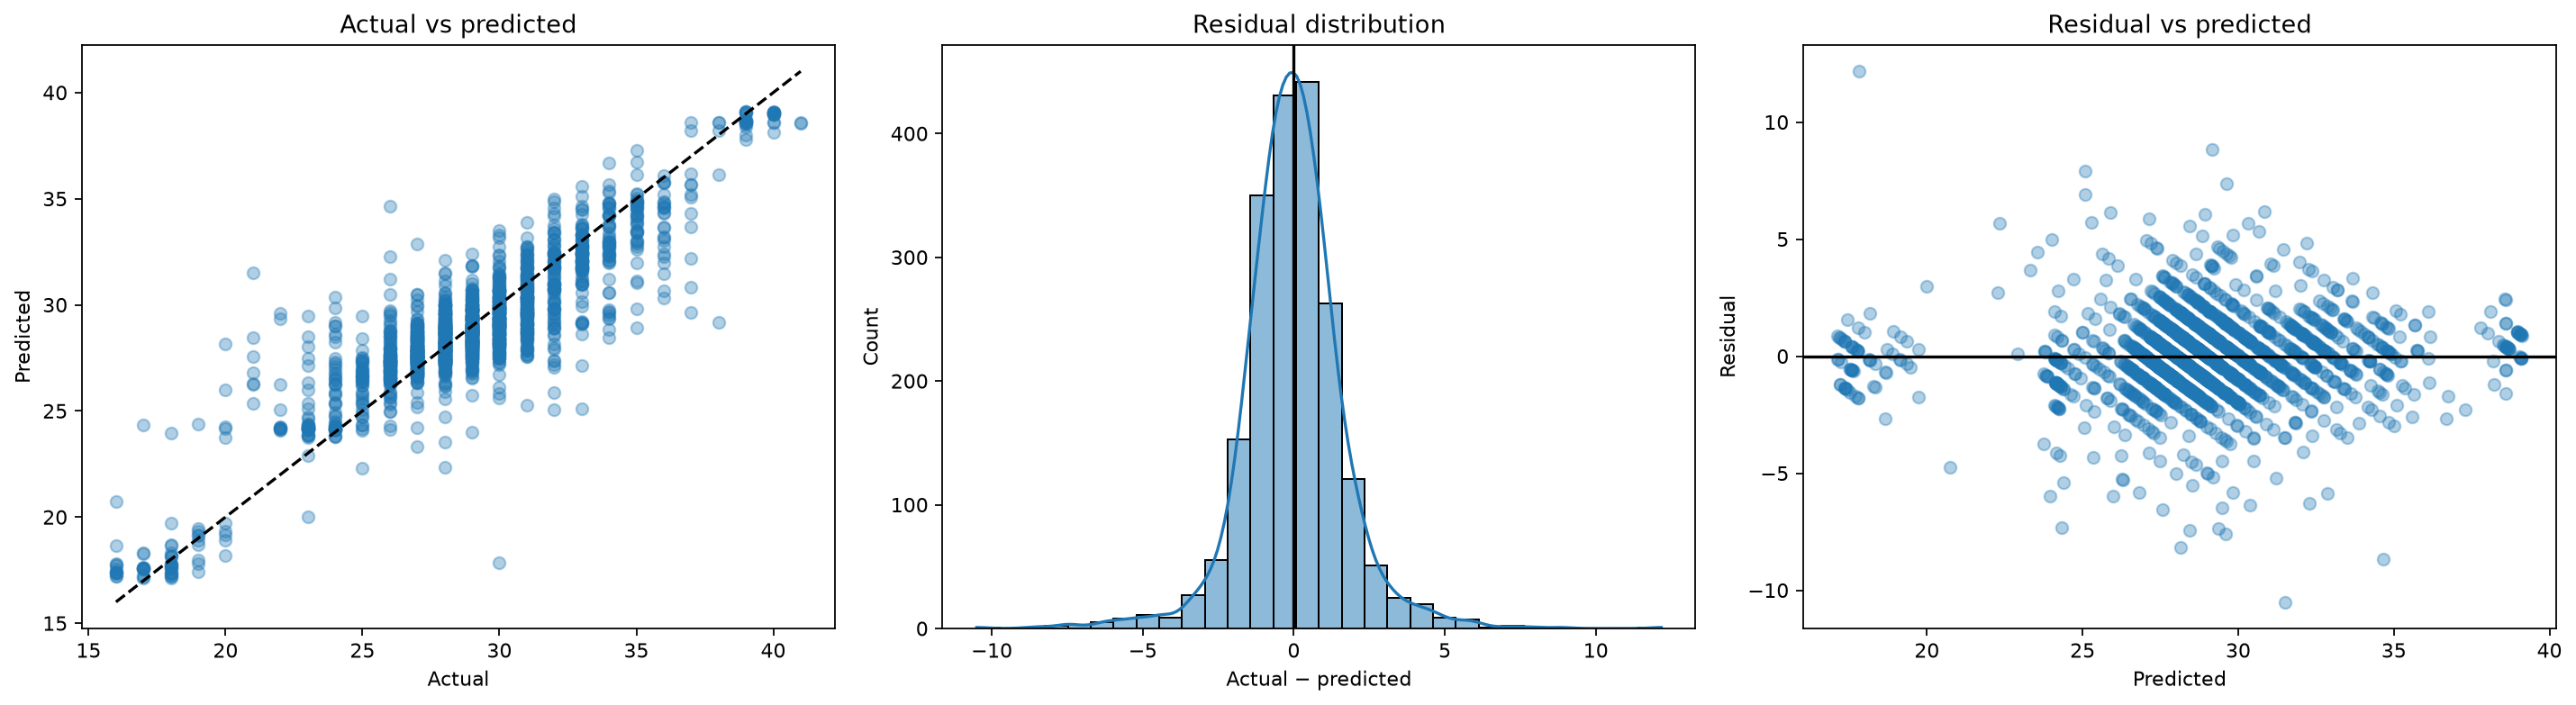

In [8]:
show_json(METRICS/'final_evaluation.json')
show_image(PLOTS/'final_diagnostics.png')

# 10 — Model Export and Inference Test

**Purpose:** Package the exact calibrated pipeline for later backend integration and demonstrate safe app input handling.

**What it does:** Exports `models/cycle_length_model.joblib` plus metadata. App histories are supplied oldest-to-newest, then the newest three are mapped to `prev_cycle_1`, `prev_cycle_2`, and `prev_cycle_3`.

**Deployment behavior:**

- 0 cycles: labelled population-median fallback.
- 1–2 cycles: labelled personal-history-average fallback.
- 3+ supported cycles: ML point prediction + 90% conformal interval.
- Clearly outside the training support range, such as `53, 56, 58` when unsupported: labelled history-average fallback, not a forced 28–30-day ML prediction.

# Team checklist before presenting

1. Run notebooks 01 through 10 in numerical order after any pipeline change.
2. Confirm the result artifacts were regenerated.
3. Use Notebook 05 as the only hyperparameter-selection source.
4. Use Notebook 09 as the only final test-performance source.
5. Explain that the data is simulated and the model is not clinical validation.
6. For an extreme history, explain the support check and labelled fallback before discussing an ML prediction.